In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

NOTEBOOK 4: RQ4 - FEATURE IMPORTANCE

[1] Loading attached dataset...
✅ Loaded: autoscout24_16and10200.csv
Dataset shape: (10200, 16)

[2] Cleaning data...
Dataset after cleaning: (10200, 16)

[3] Preparing features...
Using 8 numeric features
Features: ['mileage_km', 'power_hp', 'power_kw', 'cylinders_volume_cc', 'weight_kg', 'nr_doors', 'vehicle_age', 'brand_premium']...

[4] Train-test split and scaling...
Training: 8,160, Test: 2,040

[5] Training XGBoost model...
Model R² Score: 0.9049

[6] Extracting feature importances...

Top 10 Features:
  1. power_hp: 0.7594 (Positive)
  2. cylinders_volume_cc: 0.0867 (Positive)
  3. brand_premium: 0.0472 (Positive)
  4. weight_kg: 0.0426 (Positive)
  5. vehicle_age: 0.0293 (Negative)
  6. mileage_km: 0.0220 (Negative)
  7. nr_doors: 0.0127 (Negative)
  8. power_kw: 0.0000 (Positive)

[7] Creating Table IV...

---------------------------------------------------------------------------
TABLE IV: Top Features Contributing to Prediction
--------

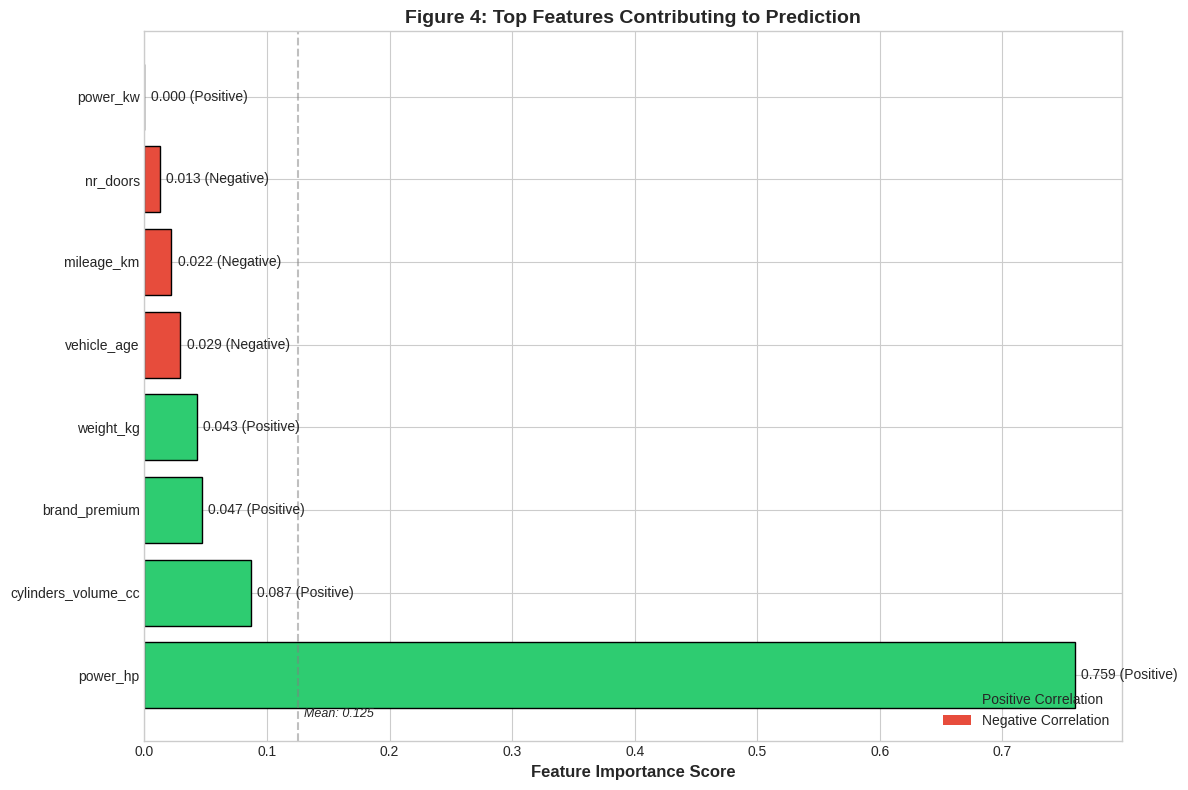

✅ Saved: /kaggle/working/Figure4_Feature_Importance.pdf

NOTEBOOK 4 COMPLETE

🔑 Most Important Feature: power_hp
   Importance Score: 0.7594

📁 Output saved to: /kaggle/working


In [1]:
# ==============================================================================
# NOTEBOOK 4: RQ4 - FEATURE IMPORTANCE
# Dataset: carsmarket analysis (attached via Data tab)
# Kernel: cars-marketanalysis-rq4
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

# Install XGBoost if needed
try:
    import xgboost
except ImportError:
    !pip install xgboost -q
    import xgboost

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("=" * 70)
print("NOTEBOOK 4: RQ4 - FEATURE IMPORTANCE")
print("=" * 70)

# ==============================================================================
# LOAD DATASET
# ==============================================================================
print("\n[1] Loading attached dataset...")

input_dir = '/kaggle/input'
df = None

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(root, file))
            print(f"✅ Loaded: {file}")
            break
    if df is not None:
        break

if df is None:
    raise FileNotFoundError("No dataset attached. Please add your dataset via the Data tab.")

print(f"Dataset shape: {df.shape}")

# ==============================================================================
# CLEAN DATA
# ==============================================================================
print("\n[2] Cleaning data...")

def clean_mileage(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

def clean_weight(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

if 'mileage_km' in df.columns:
    df['mileage_km'] = df['mileage_km'].apply(clean_mileage)
if 'weight_kg' in df.columns:
    df['weight_kg'] = df['weight_kg'].apply(clean_weight)

numeric_cols = ['power_hp', 'power_kw', 'cylinders_volume_cc', 'nr_doors', 'vehicle_age', 'brand_premium']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna()
print(f"Dataset after cleaning: {df_clean.shape}")

# ==============================================================================
# PREPARE FEATURES AND TARGET
# ==============================================================================
print("\n[3] Preparing features...")

target_col = 'price'
if target_col not in df_clean.columns:
    for col in df_clean.columns:
        if 'price' in col.lower():
            target_col = col
            break

y = df_clean[target_col]

# Get all numeric features (excluding target)
feature_cols = [col for col in df_clean.columns if col != target_col and df_clean[col].dtype in ['int64', 'float64']]
X = df_clean[feature_cols].copy()

print(f"Using {len(feature_cols)} numeric features")
print(f"Features: {feature_cols[:10]}...")

# ==============================================================================
# TRAIN-TEST SPLIT AND SCALING
# ==============================================================================
print("\n[4] Train-test split and scaling...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

# ==============================================================================
# TRAIN XGBOOST
# ==============================================================================
print("\n[5] Training XGBoost model...")

model = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, verbosity=0)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"Model R² Score: {r2:.4f}")

# ==============================================================================
# EXTRACT FEATURE IMPORTANCES
# ==============================================================================
print("\n[6] Extracting feature importances...")

importances = model.feature_importances_
feature_names = X.columns.tolist()

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

def get_direction(feature):
    """Calculate correlation with target"""
    corr = np.corrcoef(X_train[feature], y_train)[0, 1]
    return 'Positive' if corr > 0 else 'Negative'

feature_df['Direction'] = feature_df['Feature'].apply(get_direction)

print("\nTop 10 Features:")
for i, (_, row) in enumerate(feature_df.head(10).iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Importance']:.4f} ({row['Direction']})")

# ==============================================================================
# CREATE TABLE IV
# ==============================================================================
print("\n[7] Creating Table IV...")

print("\n" + "-" * 75)
print("TABLE IV: Top Features Contributing to Prediction")
print("-" * 75)
print(f"{'Rank':<6} {'Feature Name':<30} {'Importance':<15} {'Direction':<12}")
print("-" * 75)
for i, (_, row) in enumerate(feature_df.head(10).iterrows(), 1):
    print(f"{i:<6} {row['Feature']:<30} {row['Importance']:<15.4f} {row['Direction']:<12}")
print("-" * 75)

output_dir = '/kaggle/working'
feature_df.to_csv(f'{output_dir}/TableIV_Feature_Importance.csv', index=False)
print(f"\n✅ Saved: {output_dir}/TableIV_Feature_Importance.csv")

# ==============================================================================
# CREATE FIGURE 4
# ==============================================================================
print("\n[8] Creating Figure 4...")

fig, ax = plt.subplots(figsize=(12, 8))

top10 = feature_df.head(10)
colors = ['#e74c3c' if d == 'Negative' else '#2ecc71' for d in top10['Direction']]

bars = ax.barh(top10['Feature'], top10['Importance'], color=colors, edgecolor='black', linewidth=1)
ax.set_xlabel('Feature Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Figure 4: Top Features Contributing to Prediction', fontsize=14, fontweight='bold')

for bar, imp, direction in zip(bars, top10['Importance'], top10['Direction']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{imp:.3f} ({direction})', va='center', fontsize=10)

# Add mean line
mean_imp = top10['Importance'].mean()
ax.axvline(x=mean_imp, color='gray', linestyle='--', alpha=0.5)
ax.text(mean_imp + 0.005, -0.5, f'Mean: {mean_imp:.3f}', fontsize=9, style='italic')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Positive Correlation'),
                   Patch(facecolor='#e74c3c', label='Negative Correlation')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f'{output_dir}/Figure4_Feature_Importance.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{output_dir}/Figure4_Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/Figure4_Feature_Importance.pdf")

# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "=" * 70)
print("NOTEBOOK 4 COMPLETE")
print("=" * 70)
print(f"\n🔑 Most Important Feature: {feature_df.iloc[0]['Feature']}")
print(f"   Importance Score: {feature_df.iloc[0]['Importance']:.4f}")
print(f"\n📁 Output saved to: {output_dir}")
print("=" * 70)